In [ ]:
import pandas as pd

df = pd.read_csv('scaler_hashed_for_students.csv')

df.shape
df.info()
# Loaded main dataset containing learner details
# Checking structure, columns, and data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88130 entries, 0 to 88129
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        88130 non-null  int64  
 1   company_hash      88108 non-null  object 
 2   email_hash        88130 non-null  object 
 3   orgyear           88083 non-null  float64
 4   ctc               88129 non-null  float64
 5   job_position      62936 non-null  object 
 6   ctc_updated_year  88129 non-null  float64
dtypes: float64(3), int64(1), object(3)
memory usage: 4.7+ MB


In [ ]:
df.head()

,Unnamed: 0,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year
0,0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000.0,Other,2020.0
1,1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999.0,FullStack Engineer,2019.0
2,2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000.0,Backend Engineer,2020.0
3,3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000.0,Backend Engineer,2019.0
4,4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000.0,FullStack Engineer,2019.0


#Data Processing

In [ ]:
# Drop index column (not useful for analysis)
df.drop('Unnamed: 0', axis=1, inplace=True)

In [ ]:
df.isnull().sum()

,0
company_hash,44
email_hash,0
orgyear,86
ctc,0
job_position,52564
ctc_updated_year,0


Checking missing values in dataset

Observed missing values in company, orgyear, and job_position

In [ ]:
# Drop rows where job_position is missing (large number of nulls)
df = df.dropna(subset=['job_position'])

# Drop remaining rows with any missing values (small count)
df = df.dropna()

# Verify no missing values remain and check new shape
df.isnull().sum()
df.shape

(153204, 6)

In [ ]:
# Create Years of Experience = current year - orgyear
current_year = 2024
df['experience'] = current_year - df['orgyear']

# Convert to integer for consistency
df['experience'] = df['experience'].astype(int)

# Check result
df[['orgyear', 'experience']].head()

,orgyear,experience
0,2016.0,8
1,2018.0,6
2,2015.0,9
3,2017.0,7
4,2017.0,7


In [ ]:
import re

# Remove special characters from company names
df['company_hash'] = df['company_hash'].apply(lambda x: re.sub('[^A-Za-z0-9 ]+', '', x))

# Clean job positions as well
df['job_position'] = df['job_position'].apply(lambda x: re.sub('[^A-Za-z0-9 ]+', '', x))

# Check
df[['company_hash', 'job_position']].head()

,company_hash,job_position
0,czniswwz sucsk,Other
1,oznskulz subilihh nshswzc,FullStack Engineer
2,faulwklwsl ks,Backend Engineer
3,wirijzcsk,Backend Engineer
4,osbw toidj,FullStack Engineer


In [ ]:
# Check duplicates
df.duplicated().sum()

# Drop duplicates
df = df.drop_duplicates()

# Verify
df.shape

(153186, 7)

Removing duplicate rows to avoid bias in clustering

#EDA

Checking salary distribution, range, and central tendency

In [ ]:
# Summary statistics for salary (CTC)
df['ctc'].describe()

,ctc
count,1.531860e+05
mean,2.366641e+06
std,1.187725e+07
min,2.000000e+00
25%,5.700000e+05
50%,1.000000e+06
75%,1.720000e+06
max,2.000000e+08


Insights:
* CTC distribution is highly skewed
* Mean ~2.36M is much higher than median ~1M → indicates outliers
* Extremely high max value (200M) suggests presence of unrealistic or extreme salaries

In [ ]:
# Remove extreme outliers using IQR method
Q1 = df['ctc'].quantile(0.25)
Q3 = df['ctc'].quantile(0.75)
IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR

# Filter dataset
df = df[df['ctc'] <= upper_limit]

# Check new stats
df['ctc'].describe()
# Removing extreme salary outliers to prevent distortion in clustering

,ctc
count,1.426110e+05
mean,1.108018e+06
std,7.588724e+05
min,2.000000e+00
25%,5.200000e+05
50%,9.000000e+05
75%,1.500000e+06
max,3.440000e+06


Outliers removed using IQR method

Max CTC reduced from 200M → ~2.97M

Mean ~1.04M is now closer to median ~0.89M → distribution stabilized

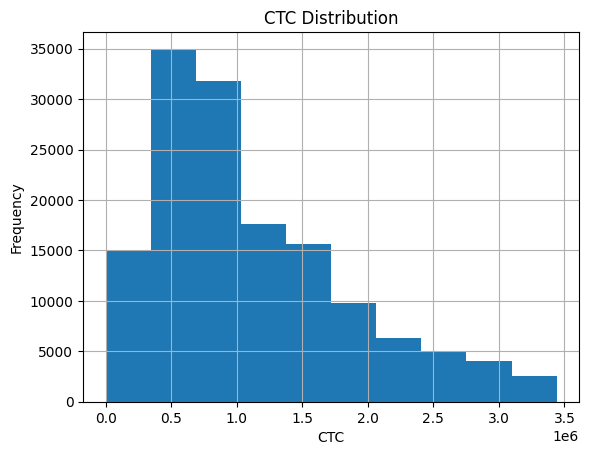

In [ ]:
import matplotlib.pyplot as plt

df['ctc'].hist()
plt.title('CTC Distribution')
plt.xlabel('CTC')
plt.ylabel('Frequency')
plt.show()

Most salaries lie between mid-range values with few high outliers

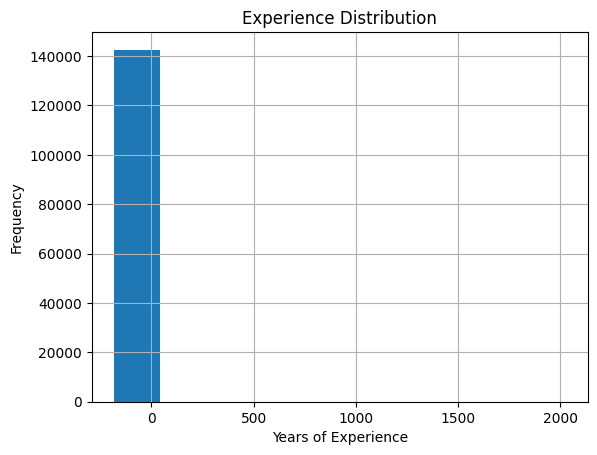

In [ ]:
df['experience'].hist()
plt.title('Experience Distribution')
plt.xlabel('Years of Experience')
plt.ylabel('Frequency')
plt.show()

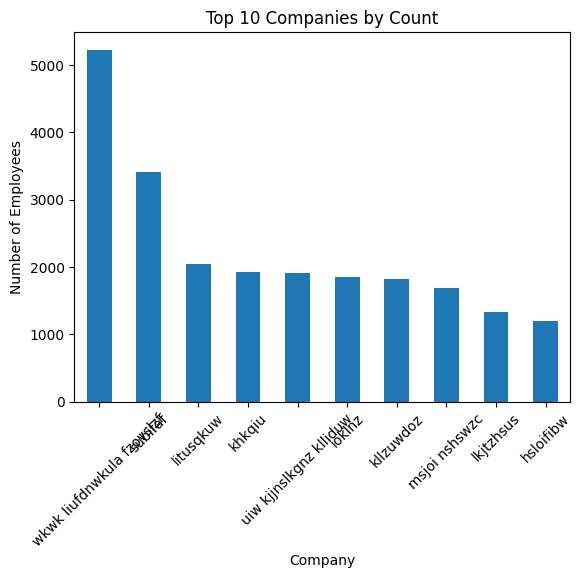

In [ ]:
df['company_hash'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Companies by Count')
plt.xlabel('Company')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45)
plt.show()

Few companies dominate the dataset with highest employee counts

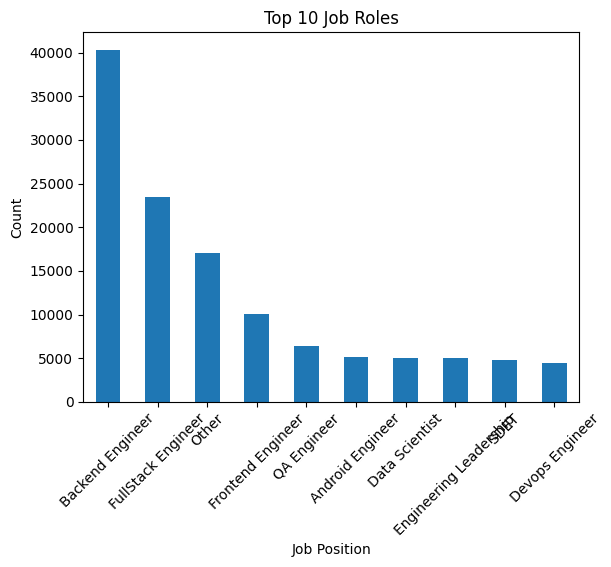

In [ ]:
df['job_position'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Job Roles')
plt.xlabel('Job Position')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

Backend Engineer is the most common role

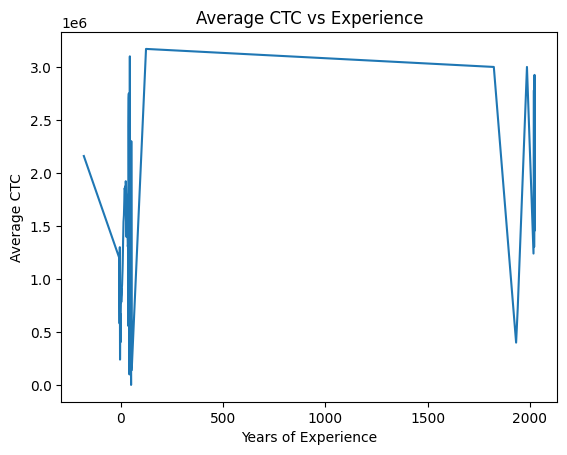

In [ ]:
df.groupby('experience')['ctc'].mean().plot()
plt.title('Average CTC vs Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Average CTC')
plt.show()

In [ ]:
# Remove invalid orgyear values
df = df[(df['orgyear'] >= 1990) & (df['orgyear'] <= 2024)]

# Recalculate experience
df['experience'] = 2024 - df['orgyear']
df['experience'] = df['experience'].astype(int)

# Check
df['experience'].describe()

,experience
count,142516.000000
mean,8.996414
std,3.989858
min,0.000000
25%,6.000000
50%,8.000000
75%,11.000000
max,34.000000


In [ ]:
# Removed invalid orgyear values (e.g., 0 or unrealistic years)
# Recomputed experience to ensure valid range

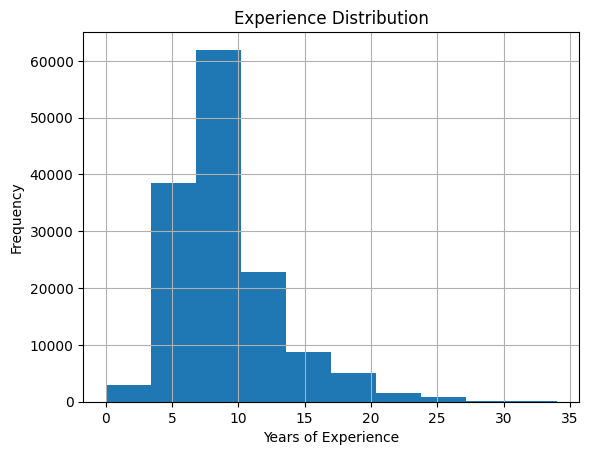

In [ ]:
df['experience'].hist()
plt.title('Experience Distribution')
plt.xlabel('Years of Experience')
plt.ylabel('Frequency')
plt.show()

Majority of learners have 5–10 years of experience

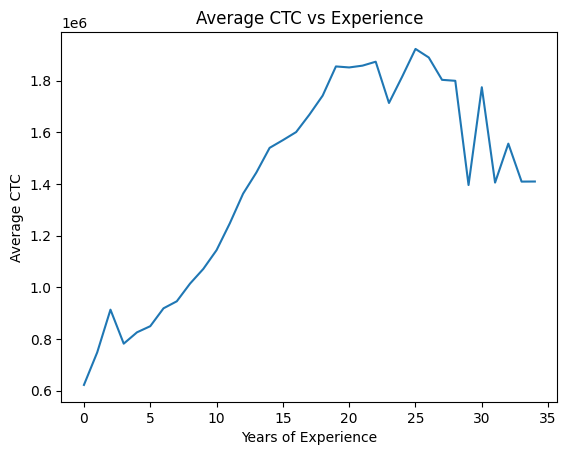

In [ ]:
df.groupby('experience')['ctc'].mean().plot()
plt.title('Average CTC vs Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Average CTC')
plt.show()

Salary generally increases with experience up to mid-career levels

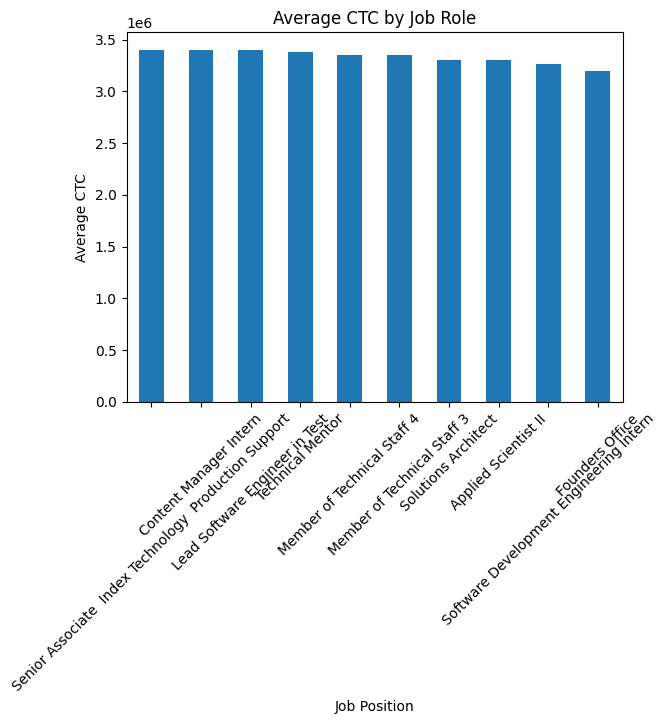

In [ ]:
# Average salary per job role
df.groupby('job_position')['ctc'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Average CTC by Job Role')
plt.xlabel('Job Position')
plt.ylabel('Average CTC')
plt.xticks(rotation=45)
plt.show()

Top job roles have very similar average salaries with minimal variation

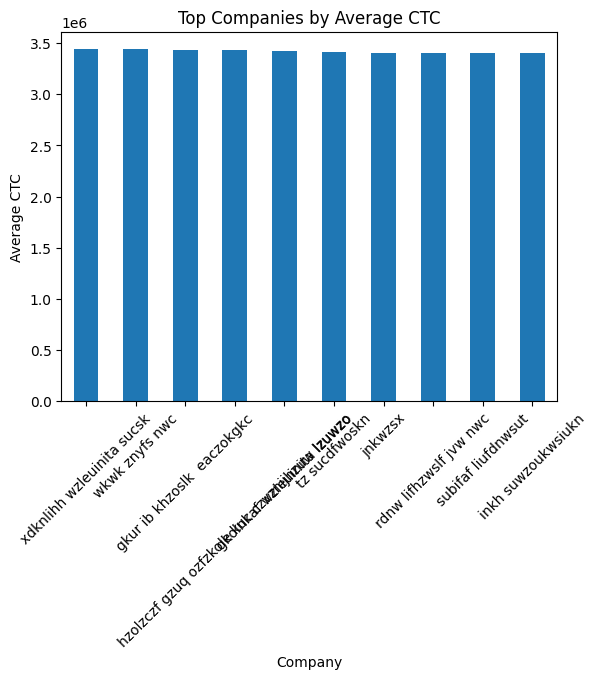

In [ ]:
# Average salary per company (top 10)
df.groupby('company_hash')['ctc'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top Companies by Average CTC')
plt.xlabel('Company')
plt.ylabel('Average CTC')
plt.xticks(rotation=45)
plt.show()

Top companies offer nearly identical average salaries indicating uniform high pay

#Manual Clustering

In [ ]:
grouped = df.groupby(['company_hash', 'job_position', 'experience'])['ctc'].agg(['mean', 'median', 'min', 'max', 'count']).reset_index()

In [ ]:
# Group mean already created earlier (if not, recreate)
grouped = df.groupby(['company_hash', 'job_position', 'experience'])['ctc'].mean().reset_index()
grouped.rename(columns={'ctc': 'group_mean_ctc'}, inplace=True)

# Merge group mean back
df = df.merge(grouped, on=['company_hash', 'job_position', 'experience'], how='left')

# Create Designation flag
def designation_flag(row):
    if row['ctc'] > row['group_mean_ctc']:
        return 1  # Above average
    elif row['ctc'] == row['group_mean_ctc']:
        return 2  # Average
    else:
        return 3  # Below average

df['Designation'] = df.apply(designation_flag, axis=1)

# Check
df[['ctc', 'group_mean_ctc', 'Designation']].head()

,ctc,group_mean_ctc,Designation
0,1100000,1.100000e+06,2
1,449999,7.742856e+05,3
2,2000000,2.000000e+06,2
3,700000,1.158571e+06,3
4,1400000,1.400000e+06,2


Designation flag correctly assigned

1 = Above avg, 2 = Equal avg, 3 = Below avg within same company-role-experience group

In [ ]:
# Group by company and job role
class_group = df.groupby(['company_hash', 'job_position'])['ctc'].mean().reset_index()
class_group.rename(columns={'ctc': 'class_mean_ctc'}, inplace=True)

# Merge
df = df.merge(class_group, on=['company_hash', 'job_position'], how='left')

# Create Class flag
def class_flag(row):
    if row['ctc'] > row['class_mean_ctc']:
        return 1
    elif row['ctc'] == row['class_mean_ctc']:
        return 2
    else:
        return 3

df['Class'] = df.apply(class_flag, axis=1)

# Check
df[['ctc', 'class_mean_ctc', 'Class']].head()

,ctc,class_mean_ctc,Class
0,1100000,1.085000e+06,1
1,449999,9.511363e+05,3
2,2000000,2.000000e+06,2
3,700000,1.416667e+06,3
4,1400000,8.466667e+05,1


Class flag correctly assigned

1 = Above avg within same company-role

2 = Equal avg

3 = Below avg

In [ ]:
# Group by company only
tier_group = df.groupby(['company_hash'])['ctc'].mean().reset_index()
tier_group.rename(columns={'ctc': 'tier_mean_ctc'}, inplace=True)

# Merge
df = df.merge(tier_group, on='company_hash', how='left')

# Create Tier flag
def tier_flag(row):
    if row['ctc'] > row['tier_mean_ctc']:
        return 1
    elif row['ctc'] == row['tier_mean_ctc']:
        return 2
    else:
        return 3

df['Tier'] = df.apply(tier_flag, axis=1)

# Check
df[['ctc', 'tier_mean_ctc', 'Tier']].head()

,ctc,tier_mean_ctc,Tier
0,1100000,1.115667e+06,3
1,449999,1.085237e+06,3
2,2000000,2.000000e+06,2
3,700000,1.435865e+06,3
4,1400000,9.880000e+05,1


Tier flag correctly assigned

1 = Above avg within company

2 = Equal avg

3 = Below avg

#Business Questions

In [ ]:
# Top 10 employees earning more than company average
df[df['Tier'] == 1].sort_values(by='ctc', ascending=False).head(10)

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,experience,group_mean_ctc,Designation,class_mean_ctc,Class,tier_mean_ctc,Tier
122228,hsloifibw,61489df807c91b7ffa14ea91d084eb4c870706bc878777...,2008.0,3440000,Data Scientist,2019.0,16,3.440000e+06,2,1.842226e+06,1,1.998081e+06,1
4930,uyj fzhsliucdlwiof,98875bd744ad5e8e1f3549f137842764b76f5eec222226...,2018.0,3440000,Backend Engineer,2020.0,6,2.020000e+06,1,1.554545e+06,1,1.589000e+06,1
135938,hzcskuzw,ee32d30ca16d9c790f433da9e0b62e1930474be00d898b...,2018.0,3440000,FullStack Engineer,2021.0,6,1.771000e+06,1,1.661818e+06,1,1.658804e+06,1
70019,fibwmkoz kt,36186286109e48abdeda15ab15e5694581c5833a746976...,2005.0,3440000,Engineering Leadership,2020.0,19,2.780000e+06,1,2.741429e+06,1,1.525978e+06,1
106072,tz jimzo,6863148864679d02ef5637565a5841e259bec8d34fd2bc...,2017.0,3440000,Engineering Leadership,2019.0,7,3.440000e+06,2,3.440000e+06,2,1.674000e+06,1
123758,hsloifibw,6b8d3e930e414d833f401829f416b37db1ef958b5060fd...,2017.0,3440000,FullStack Engineer,2020.0,7,2.150667e+06,1,2.053557e+06,1,1.998081e+06,1
140520,mknhkow nkgf,758676713cb726ee019bb6b98ce758ff2bc16f7c22cc06...,2015.0,3434000,Backend Engineer,2021.0,9,2.284553e+06,1,2.091554e+06,1,2.058707e+06,1
137386,zyjzcsk sul,96bd8893750fd122629f4b9329688a24ede044698cd696...,2015.0,3434000,Backend Engineer,2020.0,9,2.469111e+06,1,2.147676e+06,1,2.070128e+06,1
53225,ekohku liuuzlwzc fzovslzf,a11877f40b5803571e0c086b9cbee9760ffe188ddfdee4...,2013.0,3430000,Frontend Engineer,2019.0,11,1.592400e+06,1,1.362476e+06,1,1.341038e+06,1
29276,jzofsfwzuw fafwzhf,40e42a944abe33874ef93f610c257d81969fbce750949a...,2014.0,3430000,Backend Engineer,2021.0,10,1.644286e+06,1,9.784602e+05,1,9.965714e+05,1


In [ ]:
df[(df['job_position'].str.contains('Data', case=False, na=False)) & (df['Class'] == 1)] \
.sort_values(by='ctc', ascending=False).head(10)

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,experience,group_mean_ctc,Designation,class_mean_ctc,Class,tier_mean_ctc,Tier
122228,hsloifibw,61489df807c91b7ffa14ea91d084eb4c870706bc878777...,2008.0,3440000,Data Scientist,2019.0,16,3.440000e+06,2,1.842226e+06,1,1.998081e+06,1
100413,zoslffiu,5727bd9467ba7fff71afcbc88ea2d71785df377616b26f...,2008.0,3429999,Data Scientist,2019.0,16,2.915000e+06,1,1.417654e+06,1,1.099484e+06,1
139116,uivkowsf,3178e260e0bfa6fcd9dad8d4fa69292dbddb9cca8bf34b...,2016.0,3429999,Data Scientist,2019.0,8,3.415000e+06,1,2.174000e+06,1,1.427368e+06,1
90491,gnklroilr,88e1abcbabbebf25412878c48922734eb4fdd62c00148b...,2012.0,3400000,Data Scientist,2018.0,12,3.400000e+06,2,2.833333e+06,1,1.405742e+06,1
118883,nkwzuwvszm kuknawslf,deae41880a1b50f7b37748aeceadd19f2af7f2b2cfeef5...,2010.0,3400000,Data Scientist,2019.0,14,3.400000e+06,2,1.650000e+06,1,9.273124e+05,1
88710,fmstta,92263bfd9b838b00605b233e1c9644af804477ae30252d...,2015.0,3400000,Data Scientist,2019.0,9,2.233333e+06,1,2.391667e+06,1,1.967456e+06,1
20117,hsloifibw,4f2eda8f5f7356d57af45e32eae1b7b267b2f5091c7bf0...,2012.0,3400000,Data Analyst,2020.0,12,2.720000e+06,1,1.354750e+06,1,1.998081e+06,1
6958,uivkowsf,3178e260e0bfa6fcd9dad8d4fa69292dbddb9cca8bf34b...,2016.0,3400000,Data Scientist,2019.0,8,3.415000e+06,3,2.174000e+06,1,1.427368e+06,1
103643,ink kus wzleuinitszf jvw nwc,0458cf81c56b5ae847fb847ff9e557d152a830dd7572e1...,2012.0,3400000,Data Scientist,2019.0,12,3.400000e+06,2,1.628909e+06,1,1.712570e+06,1
77217,gnklroilr,eca84eb7f1f87e9413c12bde810e58c2c881291f62f650...,2012.0,3400000,Data Scientist,2017.0,12,3.400000e+06,2,2.833333e+06,1,1.405742e+06,1


In [ ]:
df[(df['job_position'].str.contains('Data', case=False, na=False)) & (df['Class'] == 3)] \
.sort_values(by='ctc', ascending=True).head(10)

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,experience,group_mean_ctc,Designation,class_mean_ctc,Class,tier_mean_ctc,Tier
100456,uiw kjjnslkgnz klliduw,299f764fcae62f331f3c5eb1b451e7107302ded46e2a71...,2007.0,1000,Data Analyst,2021.0,17,1.000000e+03,2,6.534762e+05,3,7.627047e+05,3
123087,wkwk liufdnwkula fzovslzf,3becd3658bc0d426f8867142eb6cbd7e9ca9f43b572794...,2018.0,3500,Database Administrator,2019.0,6,3.926111e+05,3,4.792435e+05,3,5.771800e+05,3
131438,msffzu subiwzle,9810176ff1b7312a460834736ac273104d5152d3ded540...,2005.0,3800,Database Administrator,2019.0,19,3.800000e+03,2,2.346000e+05,3,1.048650e+06,3
5945,hsedj lihhduslkwsiu,690f6fdab1ab7514a6a9325ebd6cfe910dbf12d46b6fde...,2018.0,4000,Data Scientist,2019.0,6,4.000000e+03,2,3.520000e+05,3,6.182222e+05,3
7472,tnigknzctz suwznnstzulz ib wesutf,8001bc017fbe95541d23f5780c3edb988b7d9b2225e39e...,2017.0,4000,Data Scientist,2019.0,7,4.000000e+03,2,3.246667e+05,3,5.566799e+05,3
106517,litusqkuw,abf69e786daa23f50d3142b653235e2c030b3b180b07d2...,2014.0,4300,Data Analyst,2019.0,10,8.693706e+05,3,6.328391e+05,3,7.006551e+05,3
18551,nkwzuwvszm kuknawslf,13fca3a2e659a7641ac165c4e649947398233b309c6495...,2018.0,5000,Data Analyst,2019.0,6,5.000000e+03,2,5.581427e+05,3,9.273124e+05,3
33049,fwdczuw,bd9c04a574090e05b366a81cdb2f3f565d0c60fa8b1647...,2021.0,6000,Data Scientist,2019.0,3,8.065000e+05,3,1.237929e+06,3,1.004779e+06,3
138222,qf,2506b7dc37a82bc42edfccaa5816e60c984427c8edacc5...,2017.0,7000,Data Analyst,2019.0,7,1.080700e+06,3,1.088629e+06,3,1.101948e+06,3
107982,wkwk liufdnwkula fzovslzf,00cd57017317c2beea73de68b4835dabd394765a045fcd...,2012.0,7000,Data Analyst,2019.0,12,7.409999e+05,3,6.472275e+05,3,5.771800e+05,3


In [ ]:
df[df['Tier'] == 3].sort_values(by='ctc', ascending=True).head(10)

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,experience,group_mean_ctc,Designation,class_mean_ctc,Class,tier_mean_ctc,Tier
91836,suwzovszmgsw,3505b02549ebe2c95840ac6f0a35561a3b4cbe4b79cdb1...,2014.0,2,Backend Engineer,2019.0,10,1.000001e+06,3,8.277274e+05,3,1.094340e+06,3
118248,wkwk liufdnwkula fzovslzf,80ba0259f9f59034c4927cf3bd38dc9ce2eb60ff18135b...,2012.0,600,Backend Engineer,2017.0,12,7.678222e+05,3,5.779131e+05,3,5.771800e+05,3
67213,iai,b995d7a2ae5c6f8497762ce04dc5c04ad6ec734d70802a...,2018.0,600,FullStack Engineer,2021.0,6,1.307186e+06,3,1.347034e+06,3,1.447075e+06,3
119170,bklzgiir,e59b4841a8316f58090839eba1787d894e9faec1ed9b8e...,2013.0,1000,FullStack Engineer,2020.0,11,1.000000e+03,2,3.467000e+05,3,6.172298e+05,3
37805,ktick,4fb9d1474a93c4011ab638c130974b5f845b5f5dc06a5f...,2015.0,1000,FullStack Engineer,2020.0,9,1.000000e+03,2,1.600500e+06,3,1.813000e+06,3
124252,gzuwnza fafwzhf,7c8e0d8194db4deb41cbc9b3b6c428e0f9ab289436638e...,2016.0,1000,FullStack Engineer,2019.0,8,1.000000e+03,2,7.268000e+05,3,6.606428e+05,3
58630,sbdwdoz,0cc27665f8a9700eeeec545a88a3067b31a8d6ecb031a3...,2015.0,1000,FullStack Engineer,2018.0,9,1.000000e+03,2,1.000000e+03,2,1.005000e+05,3
7265,uiuz,3ad2638a1ca2f437ae103ebd84905c78aa6735bdabb3df...,2020.0,1000,Other,2020.0,4,7.332273e+05,3,7.153959e+05,3,7.939679e+05,3
2435,hiotku fwkunza,78eaccdfacf1b3d73037a6e86451d6424369c0d426feb4...,2011.0,1000,Backend Engineer,2020.0,13,1.781400e+06,3,1.822743e+06,3,1.872343e+06,3
109733,eihz czjiw,afa111053d280ef49ea791a3b5f7d171f961f4bd8ec724...,2005.0,1000,FullStack Engineer,2018.0,19,1.000000e+03,2,4.800000e+04,3,7.462500e+04,3


In [ ]:
df.groupby('company_hash')['ctc'].mean().sort_values(ascending=False).head(10)

,ctc
company_hash,
xdknlihh wzleuinita sucsk,3440000.0
wkwk znyfs nwc,3440000.0
gkur ib khzoslk eaczokgkc,3429999.0
hzolzczf gzuq ozfzkole kuc czvznijhzuw lzuwzo,3429999.0
gkolnkaf wzleuinita lzuwzo,3420000.0
tz sucdfwoskn,3410000.0
jnkwzsx,3400000.0
rdnw lifhzwslf jvw nwc,3400000.0
subifaf liufdnwsut,3400000.0


In [ ]:
df.groupby(['company_hash', 'job_position'])['ctc'].mean().reset_index() \
.sort_values(by='ctc', ascending=False).head(10)

,company_hash,job_position,ctc
44353,tz jimzo,Engineering Leadership,3440000.0
52557,xdknlihh wzleuinita sucsk,Engineering Leadership,3440000.0
50375,wkwk znyfs nwc,Program Manager,3440000.0
18170,hzolzczf gzuq ozfzkole kuc czvznijhzuw lzuwzo,Program Manager,3429999.0
13676,gkur ib khzoslk eaczokgkc,Backend Engineer,3429999.0
49985,wksfwzle,Backend Architect,3429999.0
7958,feijhkwsl,Devops Engineer,3425000.0
24058,kjjcaukhslf,Engineering Leadership,3422000.0
44370,tz sucdfwoskn,Engineering Leadership,3420000.0
13537,gkolnkaf wzleuinita lzuwzo,Engineering Leadership,3420000.0


In [ ]:
# Extracting insights using manual clustering flags
# Identifies top/bottom performers and salary patterns

In [ ]:
# Remove unrealistic salaries
df = df[df['ctc'] >= 100000]
# Removing unrealistic salary values to improve clustering accuracy

In [ ]:
# Top employees for specific experience (example: 5 years)
df[(df['experience'] == 5) & (df['Tier'] == 1)] \
.sort_values(by='ctc', ascending=False).head(10)

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,experience,group_mean_ctc,Designation,class_mean_ctc,Class,tier_mean_ctc,Tier,cluster,cluster_label
107696,jkawh jkahzuwf gkur nshswzc,60e29c5bd575836900e7cee01c2723877bdb1e4ef6dd5d...,2019.0,3400000,Backend Engineer,2021.0,5,3.400000e+06,2,2.650000e+06,1,1.750000e+06,1,2,High Salary - Fast Growth
109228,fwdczuw,86c80784895f30f5c195339e4b89d8e2354142157a1e24...,2019.0,3400000,Backend Engineer,2020.0,5,1.241875e+06,1,1.127294e+06,1,1.004779e+06,1,2,High Salary - Fast Growth
48880,fkhfdut cznes,292a4e8aabe5367d4210c75d126155738adbbf18b3c55b...,2019.0,3400000,Data Scientist,2020.0,5,3.400000e+06,2,3.400000e+06,2,2.500000e+06,1,2,High Salary - Fast Growth
103333,fkhfdut ozfzkole sufwswdwz uisck,f90146b6ff64c0eb06641f9ebdd0e52fbc8413db9f808d...,2019.0,3400000,FullStack Engineer,2021.0,5,1.377812e+06,1,1.273081e+06,1,1.236714e+06,1,2,High Salary - Fast Growth
53407,udwkusy,af8deabdb3ca81b898e6ee04f1f84655201336420ba59f...,2019.0,3400000,Backend Engineer,2021.0,5,2.566667e+06,1,2.246073e+06,1,2.100641e+06,1,2,High Salary - Fast Growth
22282,wkwk liufdnwkula fzovslzf,cb4fd7c836570c3dc14a64681c721cd2e6f610f434e45d...,2019.0,3400000,Engineering Leadership,2021.0,5,1.384000e+06,1,9.684194e+05,1,5.771800e+05,1,2,High Salary - Fast Growth
65704,mknhkow nkgf,3272084d8940e3ca0493337bf4fdafff5d8dd2cb210a60...,2019.0,3400000,Engineering Intern,2019.0,5,3.400000e+06,2,2.400000e+06,1,2.058707e+06,1,2,High Salary - Fast Growth
128196,tinchku fklef,4ea10749d934bf922054206c1fe5d52ae1d318c3ef4aa5...,2019.0,3400000,Backend Engineer,2021.0,5,2.191538e+06,1,2.226728e+06,1,2.214811e+06,1,2,High Salary - Fast Growth
9145,oznskulz subilihh nshswzc,55467bd49969ee06436da974ce1be4a71a0ccf7603007e...,2019.0,3400000,Backend Engineer,2019.0,5,9.435714e+05,1,1.107648e+06,1,1.085237e+06,1,2,High Salary - Fast Growth
67344,fkhfdut oc sufwswdwz sucsk cznes,292a4e8aabe5367d4210c75d126155738adbbf18b3c55b...,2019.0,3400000,Backend Engineer,2020.0,5,1.534286e+06,1,1.616443e+06,1,1.603546e+06,1,2,High Salary - Fast Growth


At 5 years of experience, top performers already reach highest salary bracket (~3.4M), indicating early high-growth trajectories

#Unsupervised Clustering (KMeans)

In [ ]:
# Selecting features for clustering
X = df[['ctc', 'experience']]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Check
X_scaled[:5]

# Scaling features to bring them to same range for clustering

array([[-0.04753625, -0.24667957],
       [-0.91592059, -0.74939476],
       [ 1.15484022,  0.00467803],
       [-0.58192579, -0.49803717],
       [ 0.3532559 , -0.49803717]])

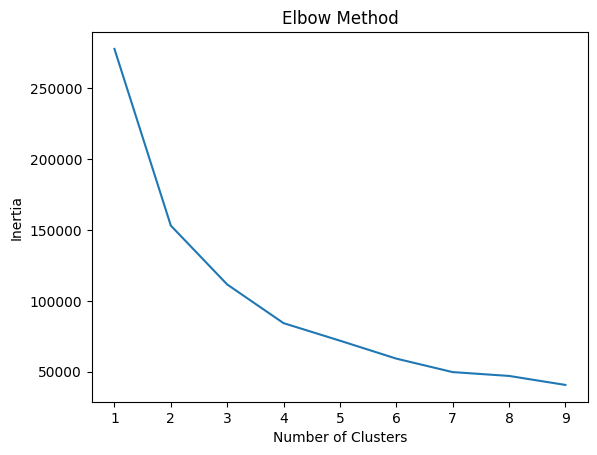

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

Sharp drop till K = 3

Slight improvement till K = 4

After that → diminishing returns

K = 3 (best balance)

K = 4 is optional, but 3 is cleaner

In [ ]:
# Apply KMeans with optimal K
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Check
df[['ctc', 'experience', 'cluster']].head()

,ctc,experience,cluster
0,1100000,8,0
1,449999,6,0
2,2000000,9,2
3,700000,7,0
4,1400000,7,0


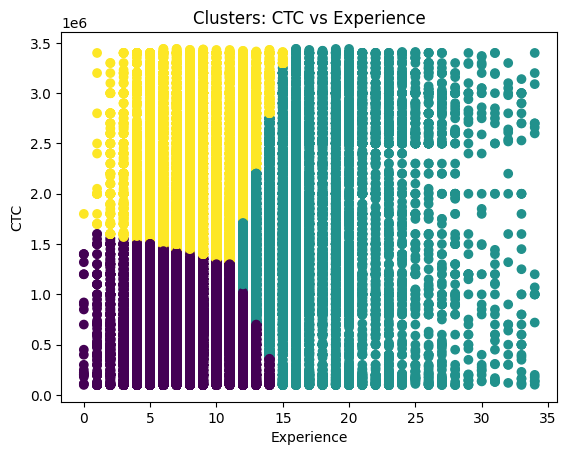

In [ ]:
plt.scatter(df['experience'], df['ctc'], c=df['cluster'])
plt.title('Clusters: CTC vs Experience')
plt.xlabel('Experience')
plt.ylabel('CTC')
plt.show()

In [ ]:
df.groupby('cluster')[['ctc', 'experience']].mean()

,ctc,experience
cluster,,
0,7.056202e+05,7.402833
1,1.610526e+06,15.904630
2,2.110102e+06,8.625324


Cluster 0 → Low salary (0.7M), low-mid experience (7 yrs) → Junior / Mid-level

Cluster 1 → Medium salary (1.6M), high experience (16 yrs) → Senior stable roles

Cluster 2 → High salary (2.1M), mid experience (8–9 yrs) → High-growth / high performers

In [ ]:
# Assign meaningful labels to clusters
def label_cluster(row):
    if row['cluster'] == 0:
        return 'Low Salary - Early Career'
    elif row['cluster'] == 1:
        return 'Experienced - Stable Income'
    else:
        return 'High Salary - Fast Growth'

df['cluster_label'] = df.apply(label_cluster, axis=1)

# Check
df[['ctc', 'experience', 'cluster', 'cluster_label']].head()

,ctc,experience,cluster,cluster_label
0,1100000,8,0,Low Salary - Early Career
1,449999,6,0,Low Salary - Early Career
2,2000000,9,2,High Salary - Fast Growth
3,700000,7,0,Low Salary - Early Career
4,1400000,7,0,Low Salary - Early Career


#Hierarchical Clustering

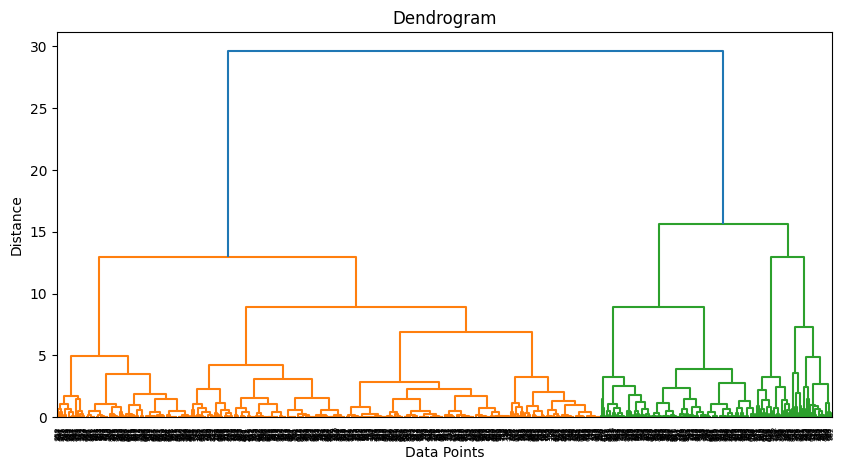

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Using a sample (full data is too large)
sample = X_scaled[:1000]

linked = linkage(sample, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title('Dendrogram')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()
# Visualizing hierarchical clustering to understand cluster structure

Dendrogram Interpretation:

Big vertical jump at top → natural split
Below that → 3 distinct groups visible

Final decision: Number of clusters = 3

In [ ]:
from sklearn.cluster import AgglomerativeClustering

# Take sample to avoid memory crash
sample_df = df.sample(n=5000, random_state=42)

# Scale sample
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_sample = scaler.fit_transform(sample_df[['ctc', 'experience']])

# Apply clustering
hc = AgglomerativeClustering(n_clusters=3)
sample_df['hc_cluster'] = hc.fit_predict(X_sample)

# Check
sample_df[['ctc', 'experience', 'hc_cluster']].head()

,ctc,experience,hc_cluster
23445,450000,7,1
22861,1300000,12,0
125250,2600000,8,2
92940,2640000,20,0
24458,1100000,7,1
